In [39]:
%pip install nltk wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import nltk
from wordcloud import WordCloud

print("NLTK version:", nltk.__version__)
print("WordCloud installed successfully!")

NLTK version: 3.10.2
WordCloud installed successfully!


In [41]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [42]:
import nltk
from wordcloud import WordCloud

print("NLTK:", nltk.__version__)
print("WordCloud: Installed")

NLTK: 3.10.2
WordCloud: Installed


In [43]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

## 1. Load Dataset

The dataset contains tweets along with their corresponding sentiment labels.
The sentiment classes are positive, negative, and neutral.

In [ ]:
#Dataset loading
df = pd.read_csv("Sentiment_Analysis.csv", encoding="latin1")

df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [ ]:
#Data inspection
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (4815, 9)

Column Names:
['textID', 'text', 'sentiment', 'Time of Tweet', 'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)', 'Density (P/Km²)']

Data Types:
textID                  str
text                    str
sentiment               str
Time of Tweet           str
Age of User             str
Country                 str
Population -2020    float64
Land Area (Km²)     float64
Density (P/Km²)     float64
dtype: object

Missing Values:
textID              1281
text                1281
sentiment           1281
Time of Tweet       1281
Age of User         1281
Country             1281
Population -2020    1281
Land Area (Km²)     1281
Density (P/Km²)     1281
dtype: int64


In [46]:
df.head()

,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,96d74cb729,Shanghai is also really exciting (precisely -...,positive,noon,21-30,Albania,2877797.0,27400.0,105.0
2,eee518ae67,"Recession hit Veronique Branquinho, she has to...",negative,night,31-45,Algeria,43851044.0,2381740.0,18.0
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265.0,470.0,164.0
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272.0,1246700.0,26.0


In [47]:
df = df[['text', 'sentiment']].copy()

df.head()

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [48]:
sentiment_counts = df['sentiment'].value_counts()

print(sentiment_counts)
sentiment_percentage = df['sentiment'].value_counts(normalize=True) * 100

print(sentiment_percentage.round(2))

sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64
sentiment
neutral     40.46
positive    31.21
negative    28.32
Name: proportion, dtype: float64


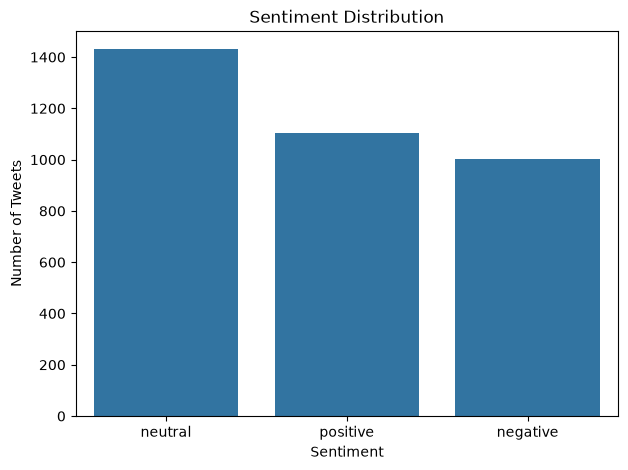

In [49]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='sentiment')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [ ]:
#Handling missing values/duplicates
print("Missing values:")
print(df.isnull().sum())


Missing values:
text         1281
sentiment    1281
dtype: int64


In [51]:
before_rows = len(df)

df = df.dropna(subset=['text', 'sentiment'])

after_rows = len(df)

print("Rows removed:", before_rows - after_rows)
print("Remaining rows:", after_rows)

Rows removed: 1281
Remaining rows: 3534


In [52]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [53]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (3534, 2)


In [ ]:
#Text preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Keep only alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]
    
    return ' '.join(tokens)

In [55]:
df['clean_text'] = df['text'].apply(preprocess_text)

df[['text', 'clean_text', 'sentiment']].head(10)

,text,clean_text,sentiment
0,Last session of the day http://twitpic.com/67ezh,last session day,neutral
1,Shanghai is also really exciting (precisely -...,shanghai also really exciting precisely skyscr...,positive
2,"Recession hit Veronique Branquinho, she has to...",recession hit veronique branquinho quit compan...,negative
3,happy bday!,happy bday,positive
4,http://twitpic.com/4w75p - I like it!!,like,positive
5,that`s great!! weee!! visitors!,thats great weee visitors,positive
6,I THINK EVERYONE HATES ME ON HERE lol,think everyone hates lol,negative
7,"soooooo wish i could, but im in school and my...",soooooo wish could im school myspace completel...,negative
8,and within a short time of the last clue all ...,within short time last clue,neutral
9,What did you get? My day is alright.. haven`...,get day alright havent done anything yet leavi...,neutral


In [56]:
empty_text_count = (df['clean_text'].str.strip() == '').sum()

print("Empty texts after preprocessing:", empty_text_count)

Empty texts after preprocessing: 12


In [57]:
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)


print("Dataset shape:", df.shape)

Dataset shape: (3522, 3)


In [58]:
X = df['clean_text']
y = df['sentiment']

In [ ]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 2817
Testing samples: 705


In [60]:
#TF-IDF 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))# TF-IDF

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training samples: 2817
Testing samples: 705
Training TF-IDF shape: (2817, 5000)
Testing TF-IDF shape: (705, 5000)


In [61]:
#Naive bayes
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")# Naive Bayes

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.
Naive Bayes model trained successfully.


In [62]:
#LOGISTIC REGRESSION
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [63]:
#   evaluating models
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred,
        average='weighted',
        zero_division=0
    )
    recall = recall_score(
        y_true, y_pred,
        average='weighted',
        zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred,
        average='weighted',
        zero_division=0
    )

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

In [64]:
evaluate_model("Naive Bayes", y_test, nb_predictions)

evaluate_model("Logistic Regression", y_test, lr_predictions)


Naive Bayes
----------------------------------------
Accuracy : 0.5830
Precision: 0.6290
Recall   : 0.5830
F1-Score : 0.5719

Logistic Regression
----------------------------------------
Accuracy : 0.6397
Precision: 0.6542
Recall   : 0.6397
F1-Score : 0.6401


In [65]:
#classification report
print("Naive Bayes Classification Report:\n")

print(
    classification_report(
        y_test,
        nb_predictions,
        zero_division=0
    )
)

Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       0.69      0.33      0.45       200
     neutral       0.50      0.78      0.61       284
    positive       0.73      0.56      0.64       221

    accuracy                           0.58       705
   macro avg       0.64      0.56      0.56       705
weighted avg       0.63      0.58      0.57       705



In [66]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)

Logistic Regression Classification Report:

              precision    recall  f1-score   support

    negative       0.66      0.53      0.58       200
     neutral       0.57      0.71      0.63       284
    positive       0.77      0.65      0.70       221

    accuracy                           0.64       705
   macro avg       0.66      0.63      0.64       705
weighted avg       0.65      0.64      0.64       705



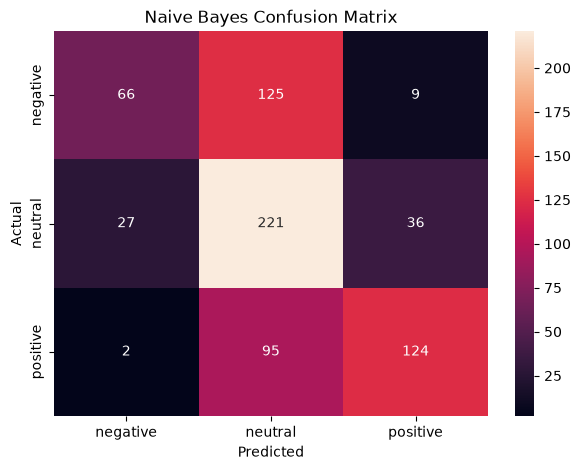

In [67]:
#confusion matrix
nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

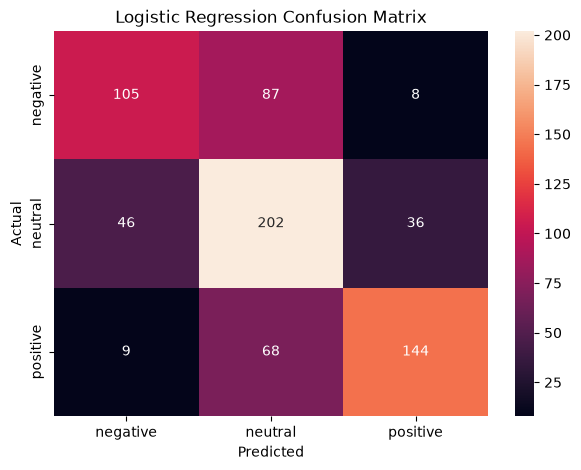

In [68]:
#confusion matrix for Logistic Regression
lr_cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=['negative', 'neutral', 'positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    xticklabels=['negative', 'neutral', 'positive'],
    yticklabels=['negative', 'neutral', 'positive']
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Model Performance Comparison

The performance of Naive Bayes and Logistic Regression is compared using
accuracy, precision, recall, and F1-score. The model with the better overall
performance will be selected based on the evaluation results.

In [69]:
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions, average='weighted', zero_division=0)
nb_recall = recall_score(y_test, nb_predictions, average='weighted', zero_division=0)
nb_f1 = f1_score(y_test, nb_predictions, average='weighted', zero_division=0)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions, average='weighted', zero_division=0)
lr_recall = recall_score(y_test, lr_predictions, average='weighted', zero_division=0)
lr_f1 = f1_score(y_test, lr_predictions, average='weighted', zero_division=0)

comparison = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [nb_accuracy, lr_accuracy],
    'Precision': [nb_precision, lr_precision],
    'Recall': [nb_recall, lr_recall],
    'F1-Score': [nb_f1, lr_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.582979,0.628969,0.582979,0.571868
1,Logistic Regression,0.639716,0.654215,0.639716,0.640114


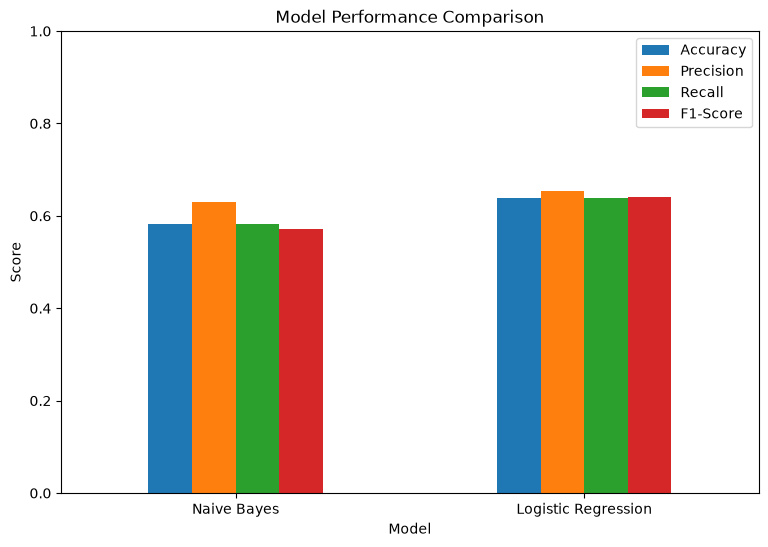

In [70]:
#comparison chart
comparison.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]].plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

## WordCloud Visualization

WordClouds provide a visual representation of frequently occurring words
within each sentiment class. Larger words represent words that occur more
frequently in the corresponding sentiment category.

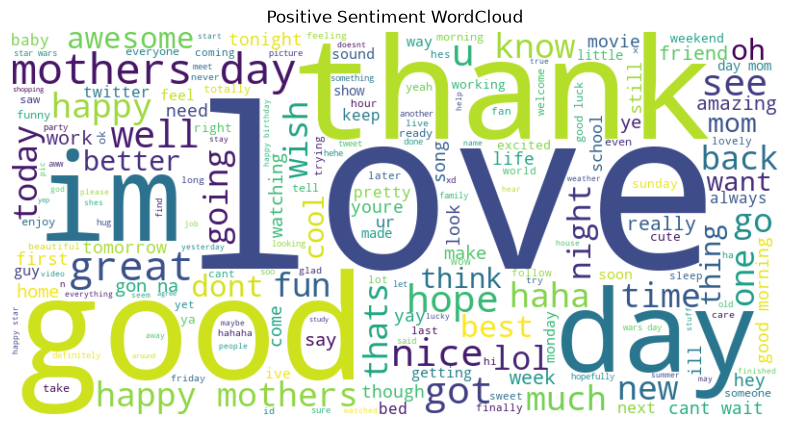

In [71]:
#positive wordcloud
positive_text = ' '.join(
    df[df['sentiment'] == 'positive']['clean_text']
)

positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Sentiment WordCloud")

plt.show()

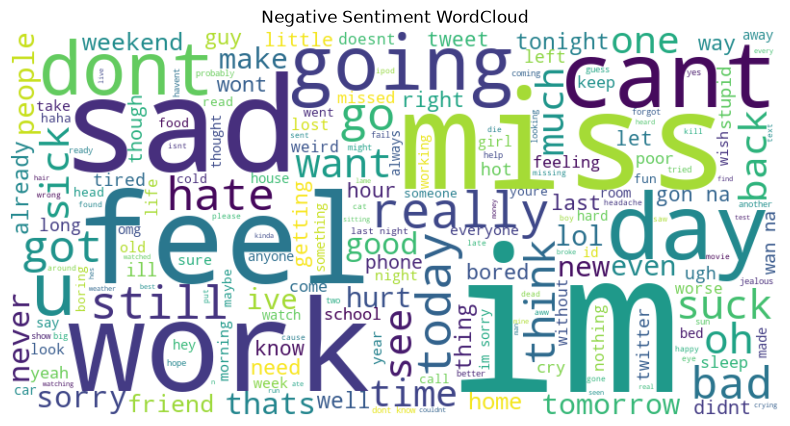

In [72]:
#negative wordcloud
negative_text = ' '.join(
    df[df['sentiment'] == 'negative']['clean_text']
)

negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Sentiment WordCloud")

plt.show()

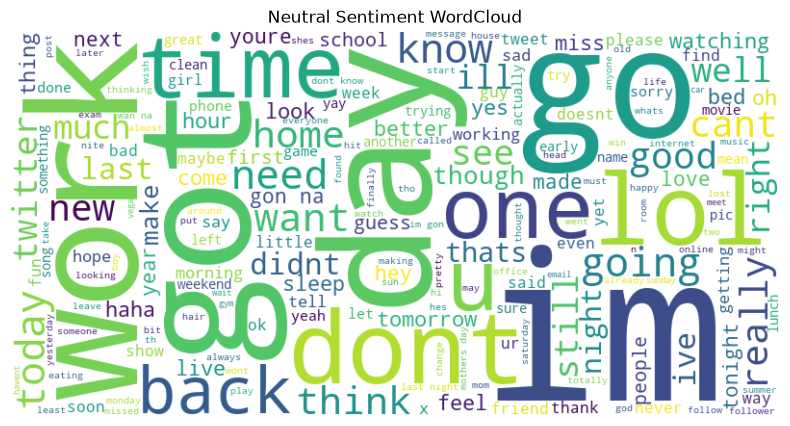

In [73]:
#neutral wordcloud
neutral_text = ' '.join(
    df[df['sentiment'] == 'neutral']['clean_text']
)

neutral_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(10, 5))
plt.imshow(neutral_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Neutral Sentiment WordCloud")

plt.show()

In [74]:
#error analysis
if lr_f1 >= nb_f1:
    best_model_name = "Logistic Regression"
    best_predictions = lr_predictions
else:
    best_model_name = "Naive Bayes"
    best_predictions = nb_predictions

print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: Logistic Regression


In [75]:
error_analysis = pd.DataFrame({
    'Original Text': X_test.values,
    'Actual Sentiment': y_test.values,
    'Predicted Sentiment': best_predictions
})

misclassified = error_analysis[
    error_analysis['Actual Sentiment'] != error_analysis['Predicted Sentiment']
]

print("Total misclassified examples:", len(misclassified))

Total misclassified examples: 254


In [76]:
misclassified.head(5)

,Original Text,Actual Sentiment,Predicted Sentiment
1,knooww hot water bottle iss whangamata without...,neutral,negative
3,well mother grandma bit kidding mode,positive,neutral
5,u say shoutout nikki please soulja boy tell em...,positive,neutral
8,long day still mow lawn,negative,positive
10,good morning rsa twitterverse please send happ...,neutral,negative


## Conclusion

This project developed a three-class sentiment analysis system for classifying
tweets as positive, negative, or neutral.

The text data was preprocessed by converting text to lowercase, removing URLs
and punctuation, tokenizing the text, and removing English stopwords. TF-IDF
was then used to convert the processed text into numerical features.

Two machine learning models, Multinomial Naive Bayes and Logistic Regression,
were trained using an 80/20 train-test split. Their performance was evaluated
using accuracy, precision, recall, F1-score, and confusion matrices.

Based on the evaluation results, the model with the higher F1-score performed
better overall on the test dataset.

Sentiment analysis can be applied to customer feedback, social-media
monitoring, product reviews, and public-opinion analysis to automatically
identify sentiment from large amounts of text.

In [77]:
df.to_csv(
    "cleaned_sentiment_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
